# Spatial statistics

<div class="custom-button-row">
    <a 
        class="custom-button custom-download-button" href="../../notebooks/07_measurement_and_quantification/measurement_and_quantification_notebook.ipynb" download>
        <i class="fas fa-download"></i> Download this Notebook
    </a>
    <a
    class="custom-button custom-download-button" href="https://colab.research.google.com/github/bobiac/bobiac-book/blob/gh-pages/colab_notebooks/07_measurement_and_quantification/measurement_and_quantification_notebook.ipynb" target="_blank">
        <img class="button-icon" src="../../_static/logo/icon-google-colab.svg" alt="Open in Colab">
        Open in Colab
    </a>
</div>

TODO: Update the links

In [1]:
# /// script
# requires-python = ">=3.10"
# dependencies = [
#     "matplotlib",
#     "numpy",
#     "scikit-image",
#     "scipy",
#     "tifffile",
#     "imagecodecs",
#     "pandas",
#     "seaborn",
#     "bobiac_tools @ git+https://github.com/bobiac/bobiac-tools.git"
# ]
# ///

## Overview

In this notebook, we will learn how to assess spatial relationships between objects. Particularly we will focus on clustering and co-localisation.

Our data consists of fluorescence images with five channels:
* Ch0: Hoechst staining, nuclei
* Ch1: Phalloidin staining, F-actin, whole cell
* Ch2: Protein A, spot pattern
* Ch3: Protein B, spot pattern
* Ch4: Protein C, spot pattern

Our questions are:
* **Are any of proteins A-C clustering?**
* **Are they co-localizing?**
* **Do they localise to the cell membrane?**

To answer these questions, we will introduce the `complete sptaial randomness Monte Carlo` method to generate random controls, the `KD-tree` for efficient neighbor search, the `nearest neighbor` metricm `Clark-Evans index` and `Ripleys K` to quantify spatial proximity.



## Importing libraries

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import skimage
import tifffile
from bobiac_tools import overlay_labels
from scipy.spatial import KDTree

## Load image, mask and spot table
First, we load all the data that we will need for the analysis.

In [3]:
path_image = "../../_static/images/quant/05_spatial_stats/images/F01_202.tif"
path_mask = "../../_static/images/quant/05_spatial_stats/masks/F01_202w1.TIF"
path_spots = "../../_static/images/quant/05_spatial_stats/spots/F01_202_spots.csv"

image = tifffile.imread(path_image)
mask = tifffile.imread(path_mask)
df_spots = pd.read_csv(path_spots)

mask = skimage.segmentation.clear_border(mask)

### Visually inspect the images, masks and spots
To be sure that the data we are working with is corrects, we visualise it here.

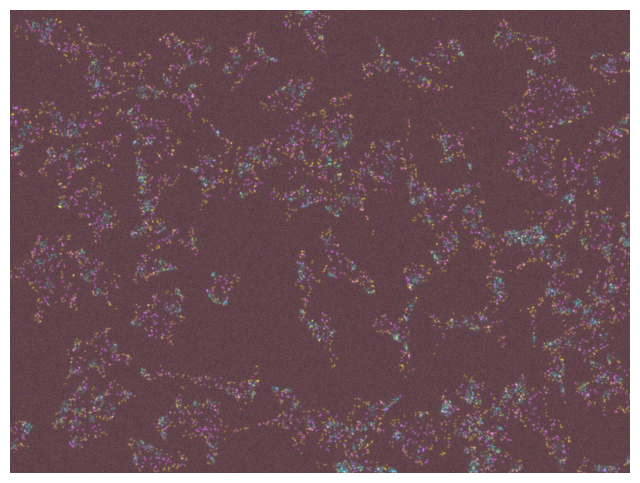

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [4]:
overlay_labels(image[2:, :, :])

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

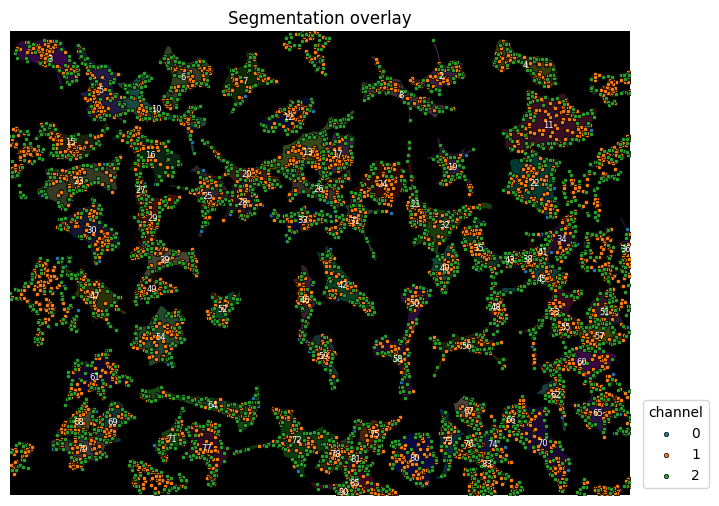

In [ ]:
overlay_labels(label_mask=mask, coordinates=df_spots)

Using the `focus` attribute in `overlay` we can zoom into single objects.

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

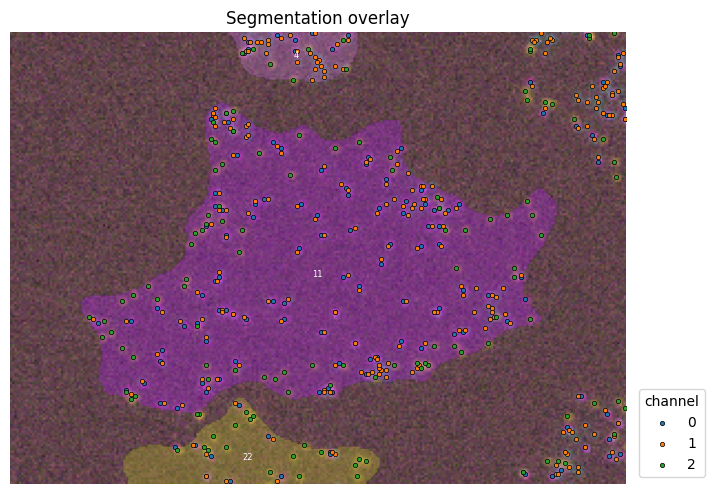

In [ ]:
overlay_labels(
    image=image[2:, :, :], label_mask=mask, coordinates=df_spots, focus_object=63
)

## 1. Are the spots clustered?
To answer this question, we need to define first what to compare to. A common comparison is to *complete spatial randomnes (CSR)*, I.e., a fully random distribution of points. We can then define a metric that measures if points are clustered and we compare that metric between the random points and our points. Here we use the average distance of each point to its nearest neighbour as the metric for clustering.

Our workflow is:
* Generate a randomly distributed set of points inside each cell's cytoplasm.
* For every spot identify the closest spot within the same dataset (protein or random) and cell and measure the distance.
* Calculate average nearest neighbour distance for protein spots and random spots. The ratio of the two indicates if the dot protein dot pattern is random or clustered and is called Clark-Evans index. If it is one the distribution is random, larger than one indicates clustering.
* Calculate the p-value of the ratio using comparison to multiple random patterns.

To start with, we focus on protein A. 


### Map spots to cells and count spots per cell
We need to know how many points are within each cell to place the same number of random points in the next step. If we would generate more or less random points, we would arificially measure clustering or dispersion.

First we generate a dataframe for the cells by using `regionprops_table`.

In [8]:
df_cell = pd.DataFrame(
    skimage.measure.regionprops_table(mask, properties=["area", "label"])
)
print(df_cell)

      area  label
0   4669.0      2
1   7866.0      3
2   6945.0      4
3   9735.0      5
4   7749.0      6
..     ...    ...
72  9504.0     80
73  2878.0     81
74  1881.0     83
75  4198.0     85
76   441.0     90

[77 rows x 2 columns]


Then we count the spots per cell (like in Exercise B: Nested Objects).

In [9]:
# map the cell label to the spots
df_spots["label_cell"] = mask[df_spots["y"].astype(int), df_spots["x"].astype(int)]
# delete spots in the background
df_spots = df_spots.loc[df_spots["label_cell"] != 0]
# count number of spots per cell label
mapping_spots = (
    df_spots.loc[df_spots["channel"] == 0]["label_cell"].value_counts().reset_index()
)
# add the cell count to the cell dataframe
df_cell = df_cell.merge(
    mapping_spots, left_on="label", right_on="label_cell", how="inner"
).drop(columns="label_cell")
print(df_spots)
print(df_cell)

       channel     y    x  label_cell
28           0   119  984           2
29           0    72  990           2
30           0   122  950           2
31           0   114  912           2
32           0    92  960           2
...        ...   ...  ...         ...
12607        2  1029  764          85
12670        2  1031  732          90
12671        2  1038  755          90
12672        2  1035  736          90
12673        2  1038  768          90

[10813 rows x 4 columns]
      area  label  count
0   4669.0      2     23
1   7866.0      3     39
2   6945.0      4     34
3   9735.0      5     48
4   7749.0      6     38
..     ...    ...    ...
72  9504.0     80     47
73  2878.0     81     14
74  1881.0     83      9
75  4198.0     85     20
76   441.0     90      2

[77 rows x 3 columns]


/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'count'}>)

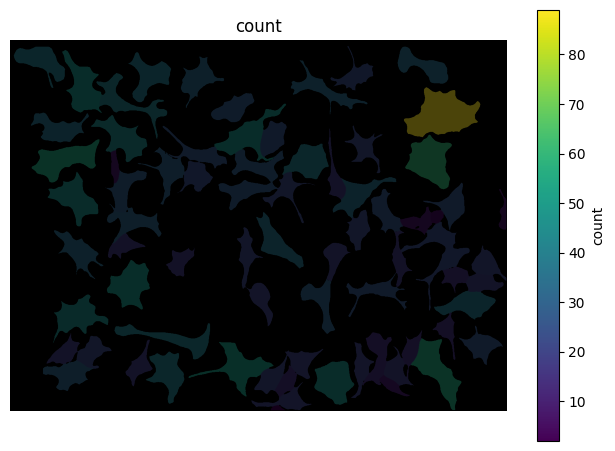

In [ ]:
overlay_labels(label_mask=mask, df=df_cell, id_col="label", measurement_col="count")

### Generate random points
Let's generate our first set of random points. To make it more transparent, let's focus on a single cell first.

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

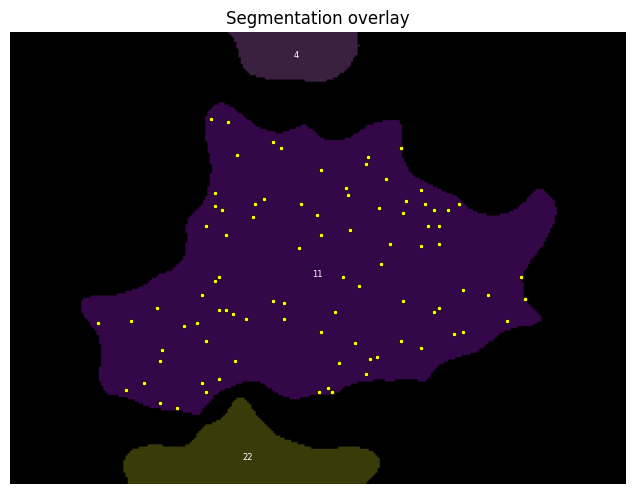

In [ ]:
cell_id = 11
spots = df_spots.loc[(df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()

overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

We can use a pre-written function to generate the random points. In short, what it does is:
* It calculates the bounding box of the cell (the box that touches the edge of the cell at every side).
* It draws random points inside that box and tests if they fall within the cell.
    * If not, the point is discarded.
    * If it is within the cell it is kept.
This sequence is repeated until the cell contains the specified number of points.

This procedure is necessary since cells have irregular shapes.

In [12]:
def random_points_in_mask(mask, cell_label, n):
    """
    Generate n random points uniformly distributed within a labeled cell region.

    Points are placed continuously using rejection sampling:
    candidate points are drawn uniformly from the bounding box of the cell and
    accepted only if they fall within the cell mask. This correctly handles
    irregular cell shapes and serves as a null model for Complete Spatial
    Randomness (CSR).

    Parameters
    ----------
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID
        and background is 0.
    cell_label : int
        ID of the cell to sample within.
    n : int
        Number of random points to generate.

    Returns
    -------
    points : (n, 2) numpy array
        Random point coordinates in (row, col) / (y, x) order.
    """
    ys, xs = np.where(mask == cell_label)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()
    points = []
    while len(points) < n:
        y = np.random.uniform(y_min, y_max)
        x = np.random.uniform(x_min, x_max)
        if mask[int(round(y)), int(round(x))] == cell_label:
            points.append([y, x])
    return np.array(points)

Look up how many points are in our cell of interest.

In [13]:
n_points = df_cell.loc[df_cell["label"] == cell_id]["count"].values[0]
print(n_points)

89


Create the same number of random points inside that cell.

In [14]:
rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
rnd_points.shape

(89, 2)

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

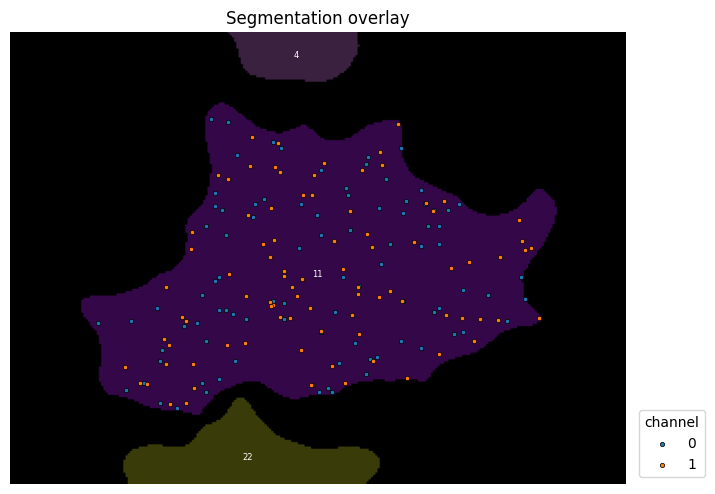

In [ ]:
overlay_labels(label_mask=mask, coordinates=[spots, rnd_points], focus_object=cell_id)

### Identify nearest neighbours and measure the distance to them.
Now that we have two sets of points, our measured spots and the random control, we can find the nearest neighbour of every point and calculate the distance. For that we we will use a `KD tree`, a spatial partitioning algorithm that identities neighbours very effectively.

The syntax for the KD tree function is a bit strange at first.

`KDTree(points_A)` builds the KD tree data structure. The distance to the nearest neighbours can be computed using `.query(points_B, k=k)`. This measures the distance from every point in `points_B` to the `k` nearest neighbours in `points_A`. If the two point sets are the same (like in our case), the first distance will be 0, since it is the distance from each point to itself.

In [16]:
dist_spots, _ = KDTree(spots).query(
    spots, k=2
)  # the query returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
print(dist_spots)

[[ 0.         11.40175425]
 [ 0.          5.09901951]
 [ 0.          8.24621125]
 [ 0.          9.8488578 ]
 [ 0.          6.        ]
 [ 0.          8.06225775]
 [ 0.          5.83095189]
 [ 0.          6.32455532]
 [ 0.          4.47213595]
 [ 0.         13.41640786]
 [ 0.          3.16227766]
 [ 0.          9.89949494]
 [ 0.         10.81665383]
 [ 0.         14.86606875]
 [ 0.          6.08276253]
 [ 0.          7.        ]
 [ 0.          8.60232527]
 [ 0.          5.09901951]
 [ 0.          2.82842712]
 [ 0.          9.8488578 ]
 [ 0.          8.94427191]
 [ 0.          3.16227766]
 [ 0.          9.48683298]
 [ 0.         13.15294644]
 [ 0.         10.19803903]
 [ 0.         15.5241747 ]
 [ 0.         11.18033989]
 [ 0.          8.24621125]
 [ 0.          9.8488578 ]
 [ 0.         11.40175425]
 [ 0.          7.28010989]
 [ 0.          6.08276253]
 [ 0.          8.24621125]
 [ 0.         10.19803903]
 [ 0.          4.47213595]
 [ 0.          3.60555128]
 [ 0.          3.16227766]
 

We do the same for the random spots.

In [17]:
dist_rnd, _ = KDTree(rnd_points).query(
    rnd_points, k=2
)  # the query returns an array of distances and an array of indices. We don't need the indicis so we assign it to the variable `_`.
print(dist_rnd)

[[ 0.          4.88756329]
 [ 0.          3.70912925]
 [ 0.          0.34610341]
 [ 0.          3.03903995]
 [ 0.          4.80297133]
 [ 0.          5.81023222]
 [ 0.          4.34536624]
 [ 0.         13.19214583]
 [ 0.          6.39461382]
 [ 0.         11.08308482]
 [ 0.          4.80297133]
 [ 0.         16.78984075]
 [ 0.         11.9352502 ]
 [ 0.          4.07365169]
 [ 0.         11.69721713]
 [ 0.          5.17001552]
 [ 0.          2.81834919]
 [ 0.          8.96444293]
 [ 0.          7.03003388]
 [ 0.         12.3621991 ]
 [ 0.          7.08323753]
 [ 0.          3.21023237]
 [ 0.          7.16231647]
 [ 0.          2.60697577]
 [ 0.          6.6066318 ]
 [ 0.          8.57543484]
 [ 0.          1.69117841]
 [ 0.          8.32299597]
 [ 0.          3.21023237]
 [ 0.          8.34556721]
 [ 0.          6.76139903]
 [ 0.          9.35038435]
 [ 0.         13.0425145 ]
 [ 0.          7.7518299 ]
 [ 0.         17.47857443]
 [ 0.          4.14429855]
 [ 0.          4.99209986]
 

Now, let's calculate the mean nearest neighbour distances for both spot patterns and compare them.

In [18]:
spot_dist_avg = dist_spots[:, 1].mean()
rnd_dist_avg = dist_rnd[:, 1].mean()
print("Mean NN distance spots:", spot_dist_avg)
print("Mean NN distance random:", rnd_dist_avg)
print("Clark-Evans index (ratio):", spot_dist_avg / rnd_dist_avg)

Mean NN distance spots: 7.382794742295512
Mean NN distance random: 7.291103127016127
Clark-Evans index (ratio): 1.0125758220233692


### Repeat with multiple random patterns
Is this a reliable comparison? No. The random pattern could be clustered by chance. To account for that and to estimate a p-value for the observed Clark-Evans index we repeat this procedure with additional random patterns.

In [ ]:
n_repeats = 10

list_rnd_dist = []  # this list holds the average NN distances of the random points for each run
list_ce_index = []  # this list holds the Clark-Evans indices for each run


for _i in range(n_repeats):
    rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
    dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
    rnd_dist_avg = dist_rnd[:, 1].mean()
    list_rnd_dist.append(rnd_dist_avg)
    list_ce_index.append(spot_dist_avg / rnd_dist_avg)

print("Mean NN distance spots:", spot_dist_avg)
print(f"Mean NN distance spots ({n_repeats} runs):", np.array(list_rnd_dist).mean())
print(f"Mean Clark-Evans index ({n_repeats} runs):", np.array(list_ce_index).mean())

Mean NN distance spots: 7.382794742295512
Mean NN distance spots (10 runs): 7.340564561115569
Mean Clark-Evans index (10 runs): 1.0101823202427551


Can we trust this metric now? A little more, but it would be great to have a p-value. We can calculate the p-value by asking 'In what fraction of the runs was the observed NN distance smaller than random?'.

In [20]:
runs_rnd_smaller = np.array(list_rnd_dist) <= spot_dist_avg
print(runs_rnd_smaller)

[False False False False  True  True  True  True  True False]


The fraction of `True`s in this list is our p-value. 

* Clustered spots → NND_observed is small → most simulations produce a larger NND → few simulations have NND_sim ≤ NND_obs → p close to 0
* Random spots → NND_observed is typical → roughly half the simulations fall below it → p ≈ 0.5

In [21]:
pval = runs_rnd_smaller.mean()
print("p-value for CE index:", pval)

p-value for CE index: 0.5


### Repeat measurements for all cells
So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

### ✍️ Exercise: Summarise the per-cell clustering analysis as a function

To make processing individual cells simpler, we can summarise our above analysis in a function called `NNDist`.
The function should have the following features:

**Parameters:**
* spots : (n, 2) numpy array
    Spot coordinates in (row, col) / (y, x) order.
* mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
* cell_id : int
    ID of the cell in mask that spots belong to.
* n_repeats : int
    Number of CSR simulations to run.

**Returns**
* spot_dist_avg : float
    Mean nearest-neighbor distance of the observed spots.
* rnd_dist_avg : float
    Mean of the per-simulation mean nearest-neighbor distances under CSR.
* clark_evans : float
    Clark-Evans index: spot_dist_avg / rnd_dist_avg.
* p_value : float
    Fraction of CSR simulations with mean NND <= spot_dist_avg.


In [22]:
def NNDist(spots, mask, cell_id, n_repeats):
    """
    Test whether spots in a cell are randomly distributed using nearest-neighbor
    distances and a Monte Carlo simulation of Complete Spatial Randomness (CSR).

    For each simulation run, n_repeats random point patterns are generated inside
    the cell mask and their mean nearest-neighbor distance is computed. The
    Clark-Evans index (observed / random NND) and a Monte Carlo p-value are
    derived from this null distribution.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    spot_dist_avg : float
        Mean nearest-neighbor distance of the observed spots.
    rnd_dist_avg : float
        Mean of the per-simulation mean nearest-neighbor distances under CSR.
    clark_evans : float
        Clark-Evans index: spot_dist_avg / rnd_dist_avg.
        < 1 indicates clustering, > 1 indicates dispersion.
    p_value : float
        Fraction of CSR simulations with mean NND <= spot_dist_avg.
        Small values (< 0.05) indicate significant clustering.
    """
    n_points = spots.shape[0]

    dist_spots, _ = KDTree(spots).query(spots, k=2)
    spot_dist_avg = dist_spots[
        :, 1
    ].mean()  # k=2: column 0 is self, column 1 is nearest neighbor

    list_rnd_dist = []
    list_ce_index = []
    for _i in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        dist_rnd, _ = KDTree(rnd_points).query(rnd_points, k=2)
        rnd_dist_avg = dist_rnd[:, 1].mean()
        list_rnd_dist.append(rnd_dist_avg)
        list_ce_index.append(spot_dist_avg / rnd_dist_avg)

    pval = (np.array(list_rnd_dist) <= spot_dist_avg).mean()

    return (
        spot_dist_avg,
        np.array(list_rnd_dist).mean(),
        np.array(list_ce_index).mean(),
        pval,
    )


NNDist(spots, mask, cell_id, 100)

(7.382794742295512, 7.4984285835823075, 0.9868337653328507, 0.35)

In [ ]:
channel = 0
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,7.542691,9.024023,0.857592,0.2
1,7866.0,3,39,7.040435,7.901921,0.897396,0.0
2,6945.0,4,34,7.250944,7.943620,0.922895,0.1
3,9735.0,5,48,7.201960,7.826532,0.924767,0.1
4,7749.0,6,38,7.557600,7.843888,0.971877,0.5
...,...,...,...,...,...,...,...
72,9504.0,80,47,7.071116,7.769559,0.919595,0.2
73,2878.0,81,14,7.357530,8.259581,0.913774,0.3
74,1881.0,83,9,5.538022,8.896801,0.644464,0.0
75,4198.0,85,20,7.137660,9.306488,0.797398,0.1


In [24]:
df_cell.loc[df_cell["label"] == cell_id]

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
8,17915.0,11,89,7.382795,7.349921,1.009917,0.5


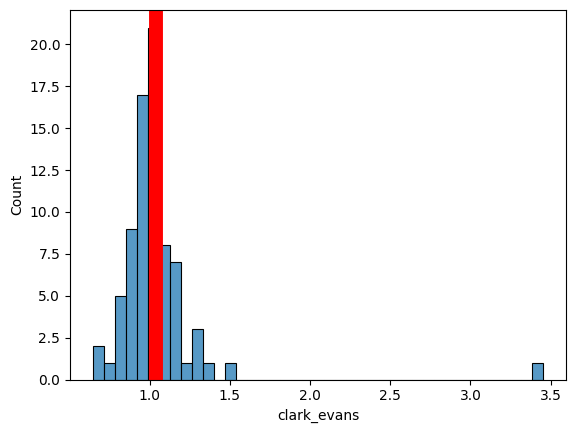

In [25]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

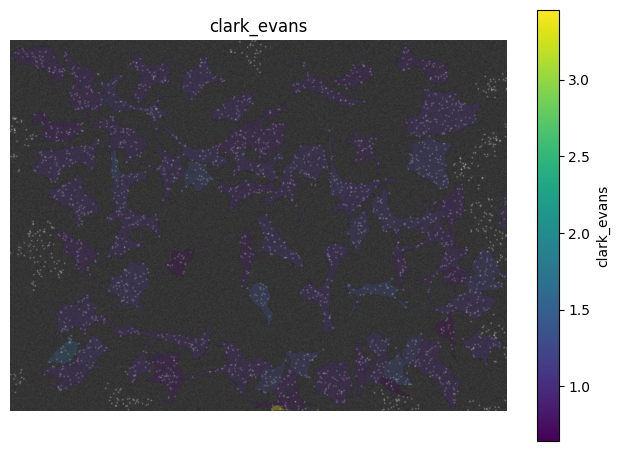

In [ ]:
overlay_labels(
    image=image[2, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

### Perform the same calculation on the other channels
Let's use the tools we developed above to see if the spots in the other channels.

**Channel 1**

In [ ]:
channel = 1
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,3.854920,4.449180,0.872931,0.1
1,7866.0,3,39,4.270026,4.986164,0.858010,0.0
2,6945.0,4,34,4.445110,4.883006,0.912384,0.1
3,9735.0,5,48,4.891864,5.426107,0.903379,0.0
4,7749.0,6,38,4.489295,5.102515,0.881792,0.0
...,...,...,...,...,...,...,...
72,9504.0,80,47,4.367094,5.203139,0.840387,0.0
73,2878.0,81,14,3.344642,3.732314,0.903353,0.1
74,1881.0,83,9,2.414088,3.157598,0.774756,0.0
75,4198.0,85,20,3.384426,4.360331,0.780185,0.0


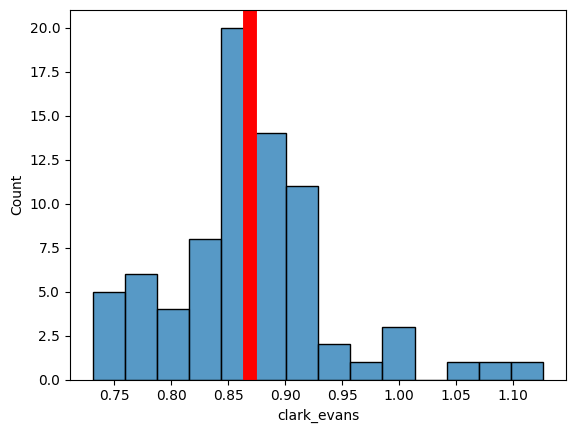

In [28]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

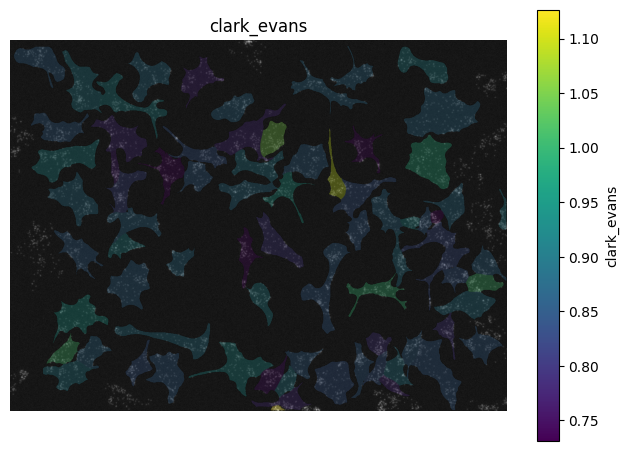

In [ ]:
overlay_labels(
    image=image[3, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

**Channel 2**

In [ ]:
channel = 2
n_repeats = 10

results = []
for _, row in df_cell.iterrows():
    # get the spots for channel 0 and the current cell
    spots_in_cell = df_spots[
        (df_spots["label_cell"] == row["label"]) & (df_spots["channel"] == channel)
    ][["y", "x"]].values
    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(NNDist(spots_in_cell, mask, row["label"], n_repeats=n_repeats))

df_cell[["nnd_observed", "nnd_random", "clark_evans", "p_value"]] = results
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value
0,4669.0,2,23,6.870816,7.268314,0.957778,0.3
1,7866.0,3,39,7.355929,7.194100,1.034872,0.7
2,6945.0,4,34,6.231751,6.738858,0.932482,0.2
3,9735.0,5,48,6.240532,7.100463,0.882680,0.0
4,7749.0,6,38,6.343255,6.947123,0.921775,0.2
...,...,...,...,...,...,...,...
72,9504.0,80,47,6.363679,8.015274,0.797571,0.0
73,2878.0,81,14,6.751128,6.744589,1.028863,0.6
74,1881.0,83,9,7.651594,6.306783,1.240001,0.8
75,4198.0,85,20,6.427021,6.488692,0.999820,0.6


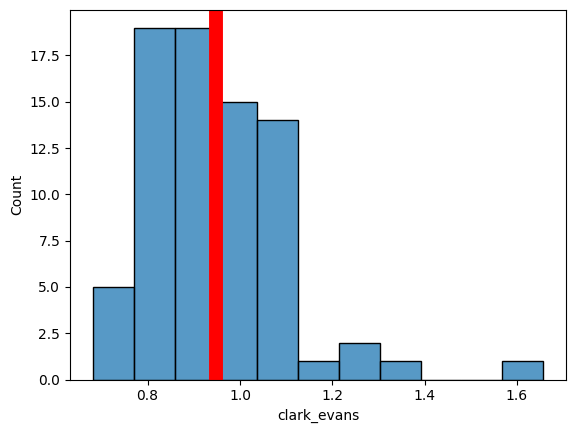

In [31]:
sns.histplot(
    df_cell,
    x="clark_evans",
)
plt.axvline(df_cell["clark_evans"].mean(), c="red", lw=10)

/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:215: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):
/var/folders/nj/7mmlcz5x01z_gtm4ncvyj1cc0000gq/T/ipykernel_86925/3150013430.py:246: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[measurement_col]) or pd.api.types.is_object_dtype(df[measurement_col]):


(<Figure size 800x800 with 2 Axes>, <Axes: title={'center': 'clark_evans'}>)

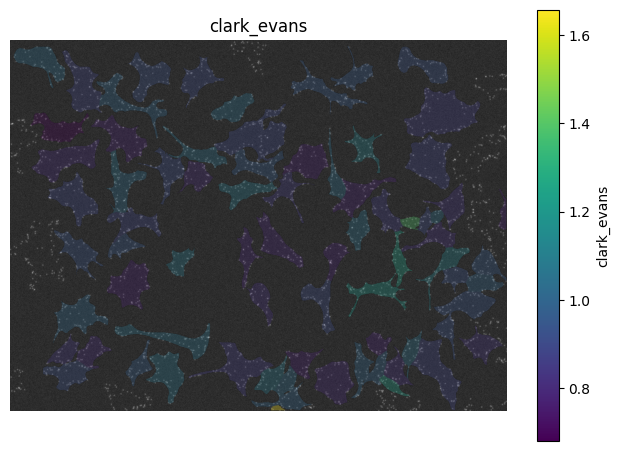

In [ ]:
overlay_labels(
    image=image[4, :, :],
    label_mask=mask,
    df=df_cell,
    id_col="label",
    measurement_col="clark_evans",
)

It seems like **protein A is not clustered**, **protein B is clustering** and protein C is a little ambiguous. 

## Ripleys L function
We know that protein B is clustered compared to random. However, we don't know what scale these clusters is.
A common method to investigate the length scales of spatial patterns is **Ripley's L function**. The idea is to calculate the density of spots around each spot for different radii and compare that to a random point pattern. The density of a random pattern is independent of the radius, while clustered points will exhibit higher density at shorter radii than longer ones. This way we can infer the average cluster size and distance between clusters.

Here, we only demonstrate the concept on the spot pattern of protein B in one cell. 

In [ ]:
from scipy.ndimage import binary_erosion


def RipleysL(spots, mask, cell_id, n_repeats, r_values=None):
    """
    Compute Ripley's L function for spots in a cell against a CSR null model,
    using a Monte Carlo envelope from simulated random point patterns.

    Returns the centered L function L(r) - r, which is 0 under CSR.
    Positive values indicate clustering at scale r, negative values indicate
    dispersion. Border correction is applied via mask erosion: only points at
    least r pixels from the cell boundary are used as source points.

    Parameters
    ----------
    spots : (n, 2) numpy array
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that spots belong to.
    n_repeats : int
        Number of CSR simulations to run.
    r_values : 1D array or None
        Radii at which to evaluate L(r) - r. Defaults to 30 values from 0
        to half the cell's effective radius.

    Returns
    -------
    r_values : 1D array
        Radii at which L(r) - r was evaluated.
    L_observed : 1D array
        L(r) - r for the observed spots.
    L_sims : (n_repeats, len(r_values)) array
        L(r) - r for each CSR simulation. Use .min(axis=0) / .max(axis=0)
        for the envelope, .mean(axis=0) for the expected value under CSR.
    """
    cell_mask = mask == cell_id
    area = cell_mask.sum()
    n_points = spots.shape[0]

    if r_values is None:
        r_max = np.sqrt(area / np.pi) * 0.5
        r_values = np.linspace(0, r_max, 30)

    # precompute eroded masks for each r — done once, not per simulation
    eroded_masks = []
    for r in r_values:
        r_int = int(np.ceil(r))
        size = 2 * r_int + 1
        cy, cx = np.ogrid[-r_int : size - r_int, -r_int : size - r_int]
        struct = cy**2 + cx**2 <= r**2
        eroded_masks.append(binary_erosion(cell_mask, structure=struct))

    def compute_L(coords):
        tree = KDTree(coords)
        K = []
        for r, eroded in zip(r_values, eroded_masks):
            valid = eroded[coords[:, 0].astype(int), coords[:, 1].astype(int)]
            n_valid = valid.sum()
            if n_valid == 0:
                K.append(np.nan)
                continue
            count = sum(len(tree.query_ball_point(p, r)) - 1 for p in coords[valid])
            K.append((area / (n_valid * n_points)) * count)
        return np.sqrt(np.array(K) / np.pi) - r_values

    L_observed = compute_L(spots)

    L_sims = []
    for _ in range(n_repeats):
        rnd_points = random_points_in_mask(mask, cell_label=cell_id, n=n_points)
        L_sims.append(compute_L(rnd_points))

    return r_values, L_observed, np.array(L_sims)

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

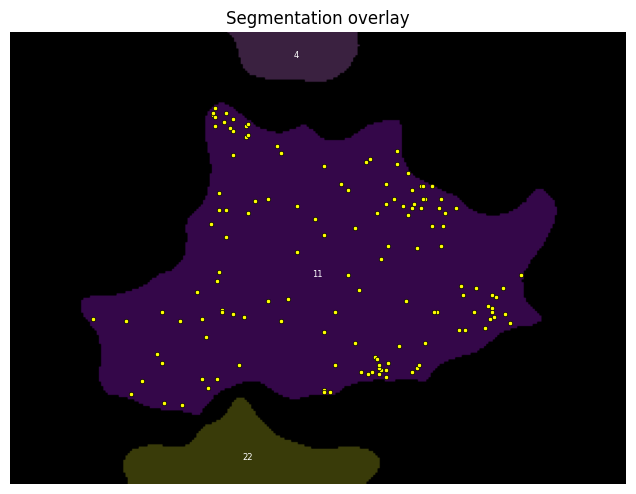

In [ ]:
cell_id = 11
spots = df_spots.loc[(df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)][
    ["y", "x"]
].to_numpy()
overlay_labels(label_mask=mask, coordinates=spots, focus_object=cell_id)

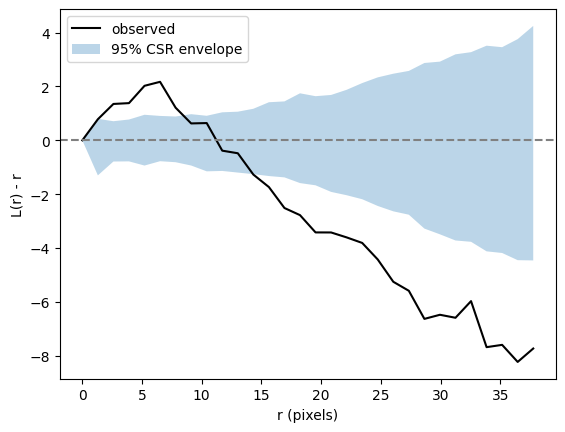

In [39]:
r_values, L_obs, L_sims = RipleysL(spots, mask, cell_id=11, n_repeats=200)

plt.plot(r_values, L_obs, color="black", label="observed")
plt.fill_between(
    r_values,
    np.percentile(L_sims, 2.5, axis=0),
    np.percentile(L_sims, 97.5, axis=0),
    alpha=0.3,
    label="95% CSR envelope",
)

plt.axhline(0, color="grey", linestyle="--")
plt.xlabel("r (pixels)")
plt.ylabel("L(r) - r")
plt.legend()

We observe clustering with scale 2-10 pixels, where the observed curve is above the 95% CSR envelope. Also, we observe dispersion (lower than expected density) for 15-35 pixels.

## 2. Do the spots co-localise?
Answering this question is very similar to answering if spots are clustered and uses the same tools. Instead of finding nearest neighbours for each point within its own set, we find the nearest neighbours of points in set A in point set B.

Our workflow is:
* Generate a randomly distributed set of points inside each cell's cytoplasm.
* For every spot in point set A identify the closest spot in point set B and measure the distance.
* For every spot in point set A idnetify the closest point in the random point set and measure the distance.
* Average the two distances across all spots in the cell.
* Calculate the ratio of the average A-B distance vs. A-random distance. This Clark-Evans index is 1 if points of set B and the random set are both distributed independently of A. <1 if A co-localises with B. >1 if A and B avoid each other.
* Calculate the p-value of the ratio using comparison to multiple random patterns.
* Reverse the direction of comparison and measure the distance of every point in B to A; repeat the analysis. 

The two directions are not interchangeable. If set B is much denser than A, every A point will happen to be near some B point even at random, making A→B appear co-localized by chance. Measuring B→A guards against this: if B is merely dense everywhere rather than specifically clustering around A, most B points will still be far from A and the ratio will stay near 1. True mutual co-localization produces small ratios in both directions.



(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

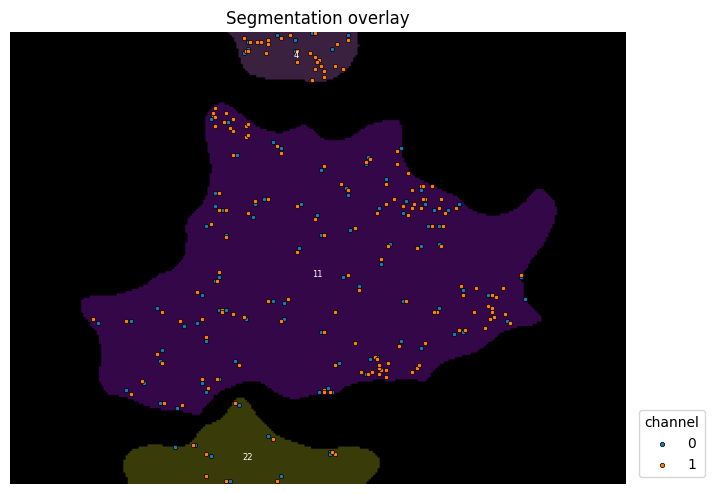

In [ ]:
overlay_labels(
    label_mask=mask,
    coordinates=df_spots.loc[df_spots["channel"].isin([0, 1])],
    focus_object=cell_id,
)

### Generate random point distribution
As before, we focus on one cell to illustrate the principles. First, we need to generate two random set of points, one each as a random distribution of the points of protein A and B (same number of points).

(<Figure size 800x587.05 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

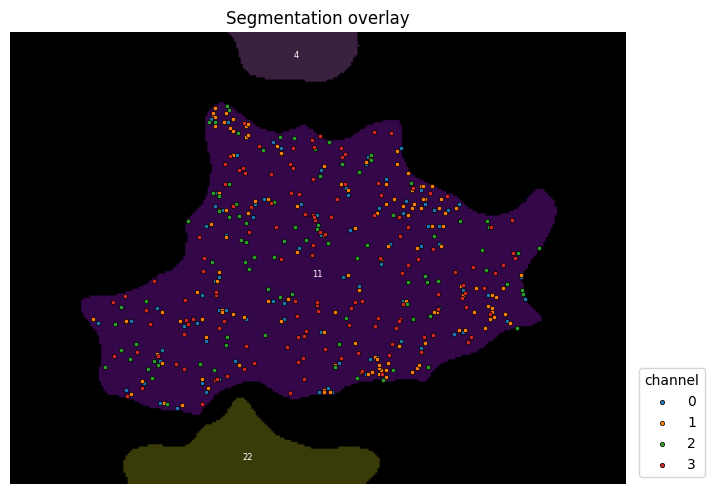

In [ ]:
cell_id = 11
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

n_A, n_B = spots_A.shape[0], spots_B.shape[0]

rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)

overlay_labels(
    label_mask=mask, coordinates=[spots_A, spots_B, rnd_A, rnd_B], focus_object=cell_id
)

## Calculate distances to nearest neighbours.
We calculate the nearest neighbour distances from 
* protein A spots to protein B spots
* protein B spots to protein A spots
* protein A spots to randomised B spots
* protein B spots to randomised A spots

In [45]:
nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

nn_ArndB = KDTree(rnd_B).query(spots_A, k=1)[0].mean()
nn_BrndA = KDTree(rnd_A).query(spots_B, k=1)[0].mean()

print("Mean NN dist. A->B:", nn_AtoB)
print("Mean NN dist. B->A:", nn_BtoA)
print("Mean NN dist. A->random(B):", nn_ArndB)
print("Mean NN dist. B->random(A):", nn_BrndA)

Mean NN dist. A->B: 1.9655708446943665
Mean NN dist. B->A: 3.207888882211614
Mean NN dist. A->random(B): 6.052734848870979
Mean NN dist. B->random(A): 7.345732727435135


Now we can calculate our Clark-Evans indices.

In [46]:
ce_AB = nn_AtoB / nn_ArndB
ce_BA = nn_BtoA / nn_BrndA

print("Clark-Evans index A->B:", ce_AB)
print("Clark-Evans index B->A:", ce_BA)

Clark-Evans index A->B: 0.3247409466583533
Clark-Evans index B->A: 0.43670100740674417


### Repeat with multiple random patterns
As before, we need to compare to multiple random patterns to 

In [47]:
n_repeats = 100

sims_AtoB, sims_BtoA = [], []
for _ in range(n_repeats):
    rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
    rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
    sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
    sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

sims_AtoB = np.array(sims_AtoB)
sims_BtoA = np.array(sims_BtoA)

print("nn_AtoB", nn_AtoB)
print("nn_BtoA", nn_BtoA)
print("nn_random_AtoB", sims_AtoB.mean())
print("nn_random_BtoA", sims_BtoA.mean())
print("ce_AtoB", nn_AtoB / sims_AtoB.mean())
print("ce_BtoA", nn_BtoA / sims_BtoA.mean())
print("pval_AtoB", (sims_AtoB <= nn_AtoB).mean())
print("pval_BtoA", (sims_BtoA <= nn_BtoA).mean())

nn_AtoB 1.9655708446943665
nn_BtoA 3.207888882211614
nn_random_AtoB 6.005467048345375
nn_random_BtoA 7.668155893260714
ce_AtoB 0.3272969161051213
ce_BtoA 0.4183390279051213
pval_AtoB 0.0
pval_BtoA 0.0


### ✍️ Exercise: Summarise the per-cell co-localisation analysis as a function

To make processing individual cells simpler, we can summarise our above analysis in a function called `CrossNN`.
The function should have the following features:

**Parameters**
spots_A, spots_B : (n, 2) numpy arrays
    Spot coordinates in (row, col) / (y, x) order.
mask : 2D numpy array
    Label mask where each cell is identified by a unique integer ID.
cell_id : int
    ID of the cell in mask that both spot sets belong to.
n_repeats : int
    Number of CSR simulations to run.

**Returns**
dict with keys:
    nn_AtoB, nn_BtoA : float
        Observed mean cross-NN distance in each direction.
    nn_random_AtoB, nn_random_BtoA : float
        Mean of simulated cross-NN distances under CSR.
    ce_AtoB, ce_BtoA : float
        Cross Clark-Evans index (observed / random). < 1 indicates
        co-localization, > 1 indicates avoidance.
    pval_AtoB, pval_BtoA : float
        Fraction of simulations with cross-NN <= observed.
        Small values indicate significant co-localization.


In [48]:
def CrossNN(spots_A, spots_B, mask, cell_id, n_repeats):
    """
    Test whether two sets of spots are more co-localized than expected under
    CSR using cross nearest-neighbor distances.

    For each point in A, the nearest neighbor in B is found (and vice versa).
    The observed mean cross-NN distances are compared to a null distribution
    where both sets are independently randomized within the cell mask.

    The two directions (A→B and B→A) can differ when the sets have different
    sizes: a small set is always close to a large one even by chance.

    Parameters
    ----------
    spots_A, spots_B : (n, 2) numpy arrays
        Spot coordinates in (row, col) / (y, x) order.
    mask : 2D numpy array
        Label mask where each cell is identified by a unique integer ID.
    cell_id : int
        ID of the cell in mask that both spot sets belong to.
    n_repeats : int
        Number of CSR simulations to run.

    Returns
    -------
    dict with keys:
        nn_AtoB, nn_BtoA : float
            Observed mean cross-NN distance in each direction.
        nn_random_AtoB, nn_random_BtoA : float
            Mean of simulated cross-NN distances under CSR.
        ce_AtoB, ce_BtoA : float
            Cross Clark-Evans index (observed / random). < 1 indicates
            co-localization, > 1 indicates avoidance.
        pval_AtoB, pval_BtoA : float
            Fraction of simulations with cross-NN <= observed.
            Small values indicate significant co-localization.
    """
    n_A, n_B = spots_A.shape[0], spots_B.shape[0]

    # observed cross-NN distances
    nn_AtoB = KDTree(spots_B).query(spots_A, k=1)[0].mean()
    nn_BtoA = KDTree(spots_A).query(spots_B, k=1)[0].mean()

    sims_AtoB, sims_BtoA = [], []
    for _ in range(n_repeats):
        rnd_A = random_points_in_mask(mask, cell_label=cell_id, n=n_A)
        rnd_B = random_points_in_mask(mask, cell_label=cell_id, n=n_B)
        sims_AtoB.append(KDTree(rnd_B).query(spots_A, k=1)[0].mean())
        sims_BtoA.append(KDTree(rnd_A).query(spots_B, k=1)[0].mean())

    sims_AtoB = np.array(sims_AtoB)
    sims_BtoA = np.array(sims_BtoA)

    return {
        "nn_AtoB": nn_AtoB,
        "nn_BtoA": nn_BtoA,
        "nn_random_AtoB": sims_AtoB.mean(),
        "nn_random_BtoA": sims_BtoA.mean(),
        "ce_AtoB": nn_AtoB / sims_AtoB.mean(),
        "ce_BtoA": nn_BtoA / sims_BtoA.mean(),
        "pval_AtoB": (sims_AtoB <= nn_AtoB).mean(),
        "pval_BtoA": (sims_BtoA <= nn_BtoA).mean(),
    }

In [49]:
spots_A = df_spots.loc[
    (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
spots_B = df_spots.loc[
    (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()
CrossNN(spots_A=spots_A, spots_B=spots_B, mask=mask, cell_id=cell_id, n_repeats=10)

{'nn_AtoB': 1.9655708446943665,
 'nn_BtoA': 3.207888882211614,
 'nn_random_AtoB': 5.973979083647299,
 'nn_random_BtoA': 7.891481421083816,
 'ce_AtoB': 0.32902204998922174,
 'ce_BtoA': 0.40650021346322107,
 'pval_AtoB': 0.0,
 'pval_BtoA': 0.0}

### Repeat measurements for all cells
So far, we have focussed on one single cell. Of course, we need to analyse all cells. 

In [ ]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    spots_A = df_spots.loc[
        (df_spots["channel"] == 0) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()
    spots_B = df_spots.loc[
        (df_spots["channel"] == 1) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        CrossNN(
            spots_A=spots_A,
            spots_B=spots_B,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_cell = pd.concat([df_cell, pd.DataFrame(results)], axis=1)
df_cell

,area,label,count,nnd_observed,nnd_random,clark_evans,p_value,nn_AtoB,nn_BtoA,nn_random_AtoB,nn_random_BtoA,ce_AtoB,ce_BtoA,pval_AtoB,pval_BtoA
0,4669.0,2,23,6.870816,7.268314,0.957778,0.3,1.742602,5.578599,4.510845,8.434161,0.386314,0.661429,0.0,0.0
1,7866.0,3,39,7.355929,7.194100,1.034872,0.7,1.776632,3.954749,5.089333,7.023586,0.349089,0.563067,0.0,0.0
2,6945.0,4,34,6.231751,6.738858,0.932482,0.2,1.764162,5.842747,4.744606,7.976643,0.371825,0.732482,0.0,0.1
3,9735.0,5,48,6.240532,7.100463,0.882680,0.0,1.777044,4.682295,5.479789,7.739054,0.324291,0.605022,0.0,0.0
4,7749.0,6,38,6.343255,6.947123,0.921775,0.2,1.730490,6.242496,5.080280,8.293208,0.340629,0.752724,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,9504.0,80,47,6.363679,8.015274,0.797571,0.0,1.715710,3.593778,5.056051,7.896370,0.339338,0.455118,0.0,0.0
73,2878.0,81,14,6.751128,6.744589,1.028863,0.6,1.504764,7.685147,3.699090,7.916698,0.406793,0.970751,0.0,0.5
74,1881.0,83,9,7.651594,6.306783,1.240001,0.8,2.093022,10.883218,3.084167,7.472577,0.678634,1.456421,0.0,1.0
75,4198.0,85,20,6.427021,6.488692,0.999820,0.6,1.648309,6.056318,4.063864,8.749001,0.405601,0.692230,0.0,0.0


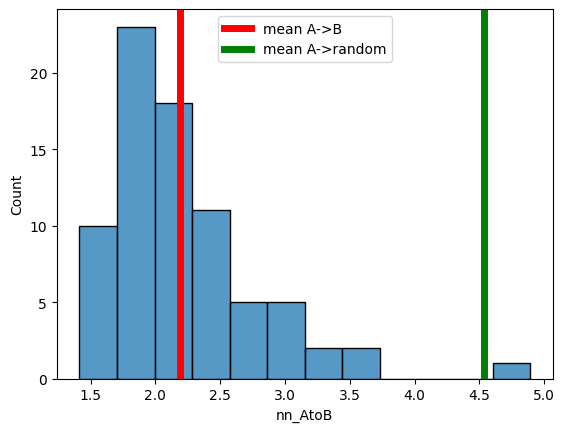

In [51]:
sns.histplot(
    df_cell,
    x="nn_AtoB",
)
plt.axvline(df_cell["nn_AtoB"].mean(), c="red", lw=5, label="mean A->B")
plt.axvline(df_cell["nn_random_AtoB"].mean(), c="green", lw=5, label="mean A->random")
plt.legend()

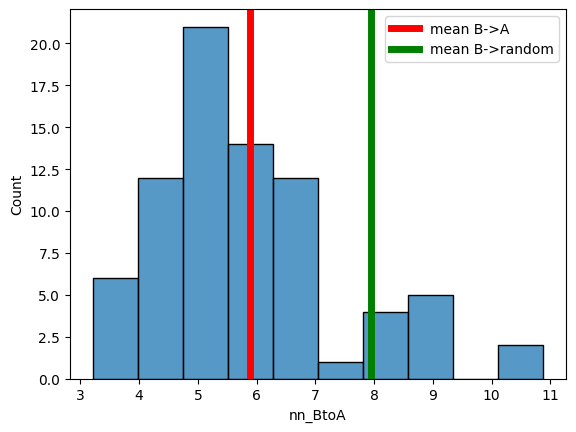

In [52]:
sns.histplot(
    df_cell,
    x="nn_BtoA",
)
plt.axvline(df_cell["nn_BtoA"].mean(), c="red", lw=5, label="mean B->A")
plt.axvline(df_cell["nn_random_BtoA"].mean(), c="green", lw=5, label="mean B->random")
plt.legend()

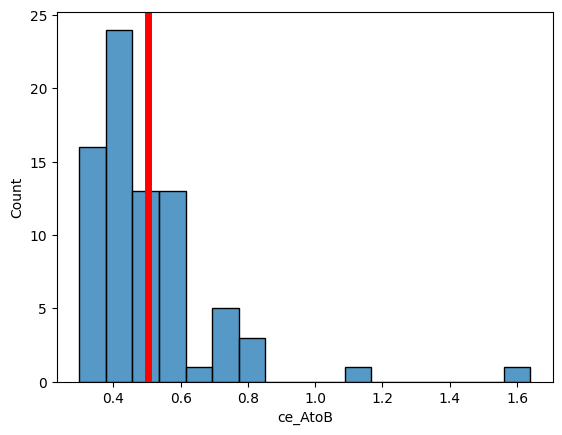

In [53]:
sns.histplot(
    df_cell,
    x="ce_AtoB",
)
plt.axvline(df_cell["ce_AtoB"].mean(), c="red", lw=5)

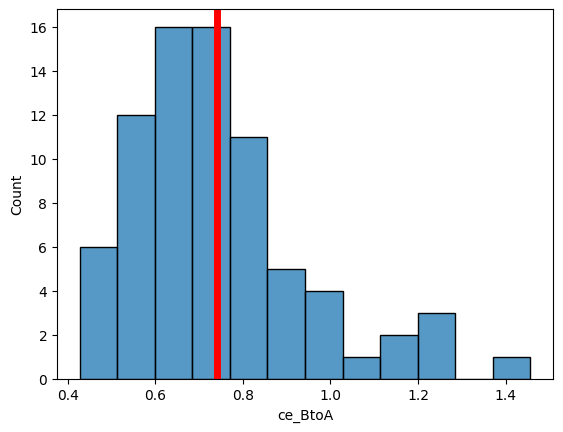

In [54]:
sns.histplot(
    df_cell,
    x="ce_BtoA",
)
plt.axvline(df_cell["ce_BtoA"].mean(), c="red", lw=5)

**Interpretation:** Almost all of protein A associates with protein B but not vice versa. 

## 3. Does Protein C localise to the cell membrane?
Another common task is to ask whether a distribution of objects is close to a certain cellular region; in this case the cell membrane. At first glance this might seem distinct from what we have done so far, but it is just a variation of co-localisation analysis. The key is to transform the region into a set of points. This way we can do the exact same analysis as above.

### ✍️ Exercise: Perform the analysis

Use the cross nearest neighbour analysis we developed above to find out if protein C localises preferentially to the cell membrane.

Hints: 
* The code snippet below illustrates how a boolean mask of a whole single cell can be turned into its boundary and subsequently into a list of boundary coordinates (points).
* Think carefully about which populations to randomise and compare.

(<Figure size 800x588.571 with 1 Axes>,
 <Axes: title={'center': 'Segmentation overlay'}>)

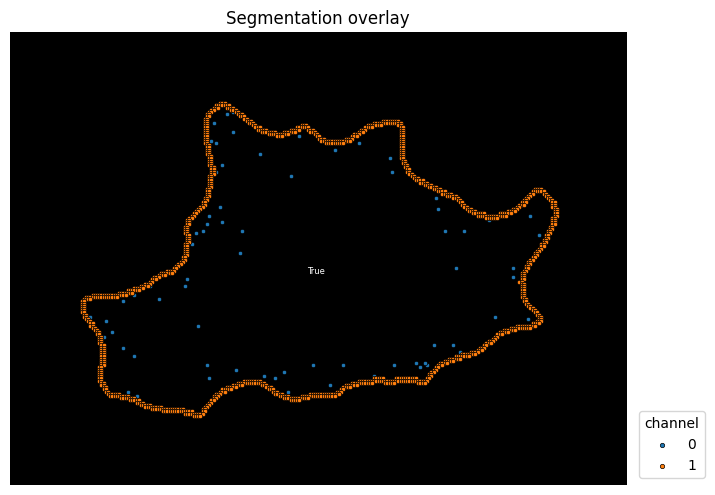

In [ ]:
from skimage.segmentation import find_boundaries

cell_id = 11

spots_C = df_spots.loc[
    (df_spots["channel"] == 2) & (df_spots["label_cell"] == cell_id)
][["y", "x"]].to_numpy()

boundary = find_boundaries(mask == cell_id)
coords = np.argwhere(boundary)

overlay_labels(label_mask=boundary, coordinates=[spots_C, coords], focus_object=True)

In [ ]:
def NNdist_target(spots_from, spots_to, mask, cell_id, n_repeats):
    """
    Calculate the nearest neighbour distance from `spots_from` to `spots_to`.
    """

    n_from = spots_from.shape[0]

    # observed NN distances
    nn_obs = KDTree(spots_to).query(spots_from, k=1)[0].mean()

    # randomised NN distances
    sims = []
    for _ in range(n_repeats):
        rnd = random_points_in_mask(mask, cell_label=cell_id, n=n_from)

        sims.append(KDTree(rnd_B).query(rnd, k=1)[0].mean())

    sims = np.array(sims)

    return {
        "nn_observed": nn_obs,
        "nn_random": sims.mean(),
        "ce": nn_obs / sims.mean(),
        "pval": (sims <= nn_obs).mean(),
    }

In [ ]:
n_repeats = 10

results = []
for cell_id in df_cell["label"].unique():
    boundary = find_boundaries(mask == cell_id)
    coords = np.argwhere(boundary)
    spots_C = df_spots.loc[
        (df_spots["channel"] == 2) & (df_spots["label_cell"] == cell_id)
    ][["y", "x"]].to_numpy()

    # calculate the NN distance, Clark-Evans index and p-value for that cell
    results.append(
        NNdist_target(
            spots_from=spots_C,
            spots_to=coords,
            mask=mask,
            cell_id=cell_id,
            n_repeats=n_repeats,
        )
    )

df_boundary = pd.DataFrame(results)
df_boundary

,nn_observed,nn_random,ce,pval
0,4.585573,192.194871,0.023859,0.0
1,4.553575,1036.505509,0.004393,0.0
2,5.152849,75.593922,0.068165,0.0
3,5.909423,913.873462,0.006466,0.0
4,5.043336,731.709090,0.006893,0.0
...,...,...,...,...
72,5.876321,726.415363,0.008089,0.0
73,5.066749,775.057406,0.006537,0.0
74,3.332884,708.945449,0.004701,0.0
75,3.951430,823.965827,0.004796,0.0


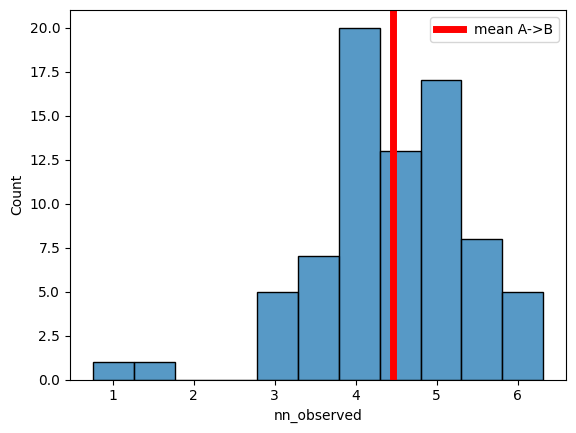

In [58]:
sns.histplot(
    df_boundary,
    x="nn_observed",
)
plt.axvline(df_boundary["nn_observed"].mean(), c="red", lw=5, label="mean A->B")
# plt.axvline(df_boundary['nn_random'].mean(), c='green', lw=5, label='mean A->random')
plt.legend()

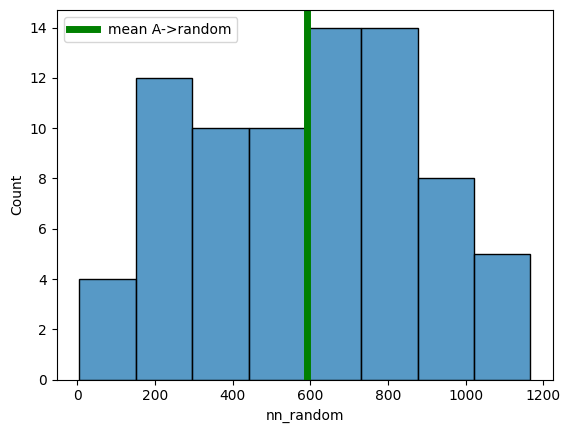

In [59]:
sns.histplot(
    df_boundary,
    x="nn_random",
)
# plt.axvline(df_boundary['nn_observed'].mean(), c='red', lw=5, label='mean A->B')
plt.axvline(df_boundary["nn_random"].mean(), c="green", lw=5, label="mean A->random")
plt.legend()

(0.0, 0.1)

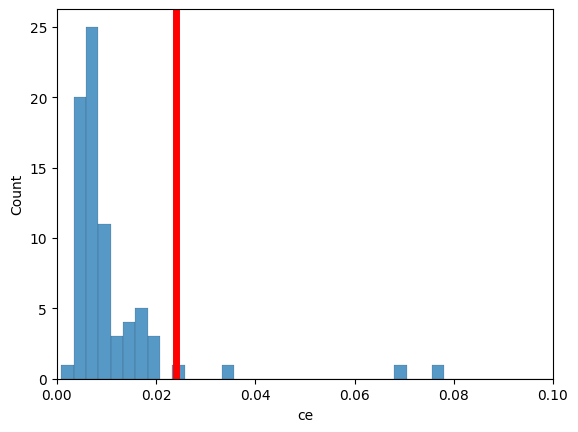

In [63]:
sns.histplot(
    df_boundary,
    x="ce",
)
plt.axvline(df_boundary["ce"].mean(), c="red", lw=5)
plt.xlim(0, 0.1)

So, definitely, Protein C localises close to the cell membrane with an average distance of 4.5 pixels.